# Predictive Modeling

This notebook builds multiple machine learning models using the cleaned Titanic dataset generated in Part A. The workflow includes data preprocessing, model training, evaluation, class imbalance handling, hyperparameter tuning, a regression side-task, model comparison, and saving the final production-ready pipeline.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_curve, roc_auc_score, 
    ConfusionMatrixDisplay,
    mean_absolute_error, root_mean_squared_error, r2_score
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import joblib


## Train-Test Split

The cleaned Titanic dataset is divided into training and testing subsets using a **stratified train-test split**, with **survived** as the target variable.


In [2]:
df = pd.read_csv('titanic.csv')

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [3]:
X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


print(f"Training Features: {X_train.shape[0]}")
print(f"Training Labels: {y_train.shape[0]}")
print(f"Testing Features: {X_test.shape[0]}")
print(f"Testing Labels: {y_test.shape[0]}")


Training Features: 711
Training Labels: 711
Testing Features: 178
Testing Labels: 178


### Justification for Stratified Splitting

The class distribution of the target variable (`survived`) is not perfectly balanced, with a higher proportion of non-survivors than survivors. A stratified train-test split preserves this class distribution in both the training and testing datasets.

Maintaining the original class proportions ensures that both subsets are representative of the overall dataset. This reduces sampling bias, enables the model to learn from both classes effectively, and provides a more reliable and unbiased evaluation of predictive performance.


## Data Preprocessing

A preprocessing pipeline is constructed to prepare the data for machine learning. Missing values are imputed, categorical features (**sex** and **embarked**) are encoded, and numerical features are standardized using **StandardScaler**.


In [4]:
num_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

cat_features = [
    "sex",
    "embarked"
]


In [5]:
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training Feature Shape: {X_train_processed.shape}")
print(f"Testing Feature Shape: {X_test_processed.shape}")


Training Feature Shape: (711, 10)
Testing Feature Shape: (178, 10)


## Model Training

Train Three Classification Models using the same training and testing split:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

Each model is fitted on the training data to learn patterns associated with passenger survival.

For the Decision Tree Classifier Model, visualize using `plot_tree()` with feature names and class labels.


In [7]:
logistic_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000))
    ]
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, oob_score=True))
    ]
)


In [8]:
logistic_regression_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['pclass','sex','age',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

In [9]:
decision_tree_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['pclass','sex','age',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

In [10]:
random_forest_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['pclass','sex','age',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

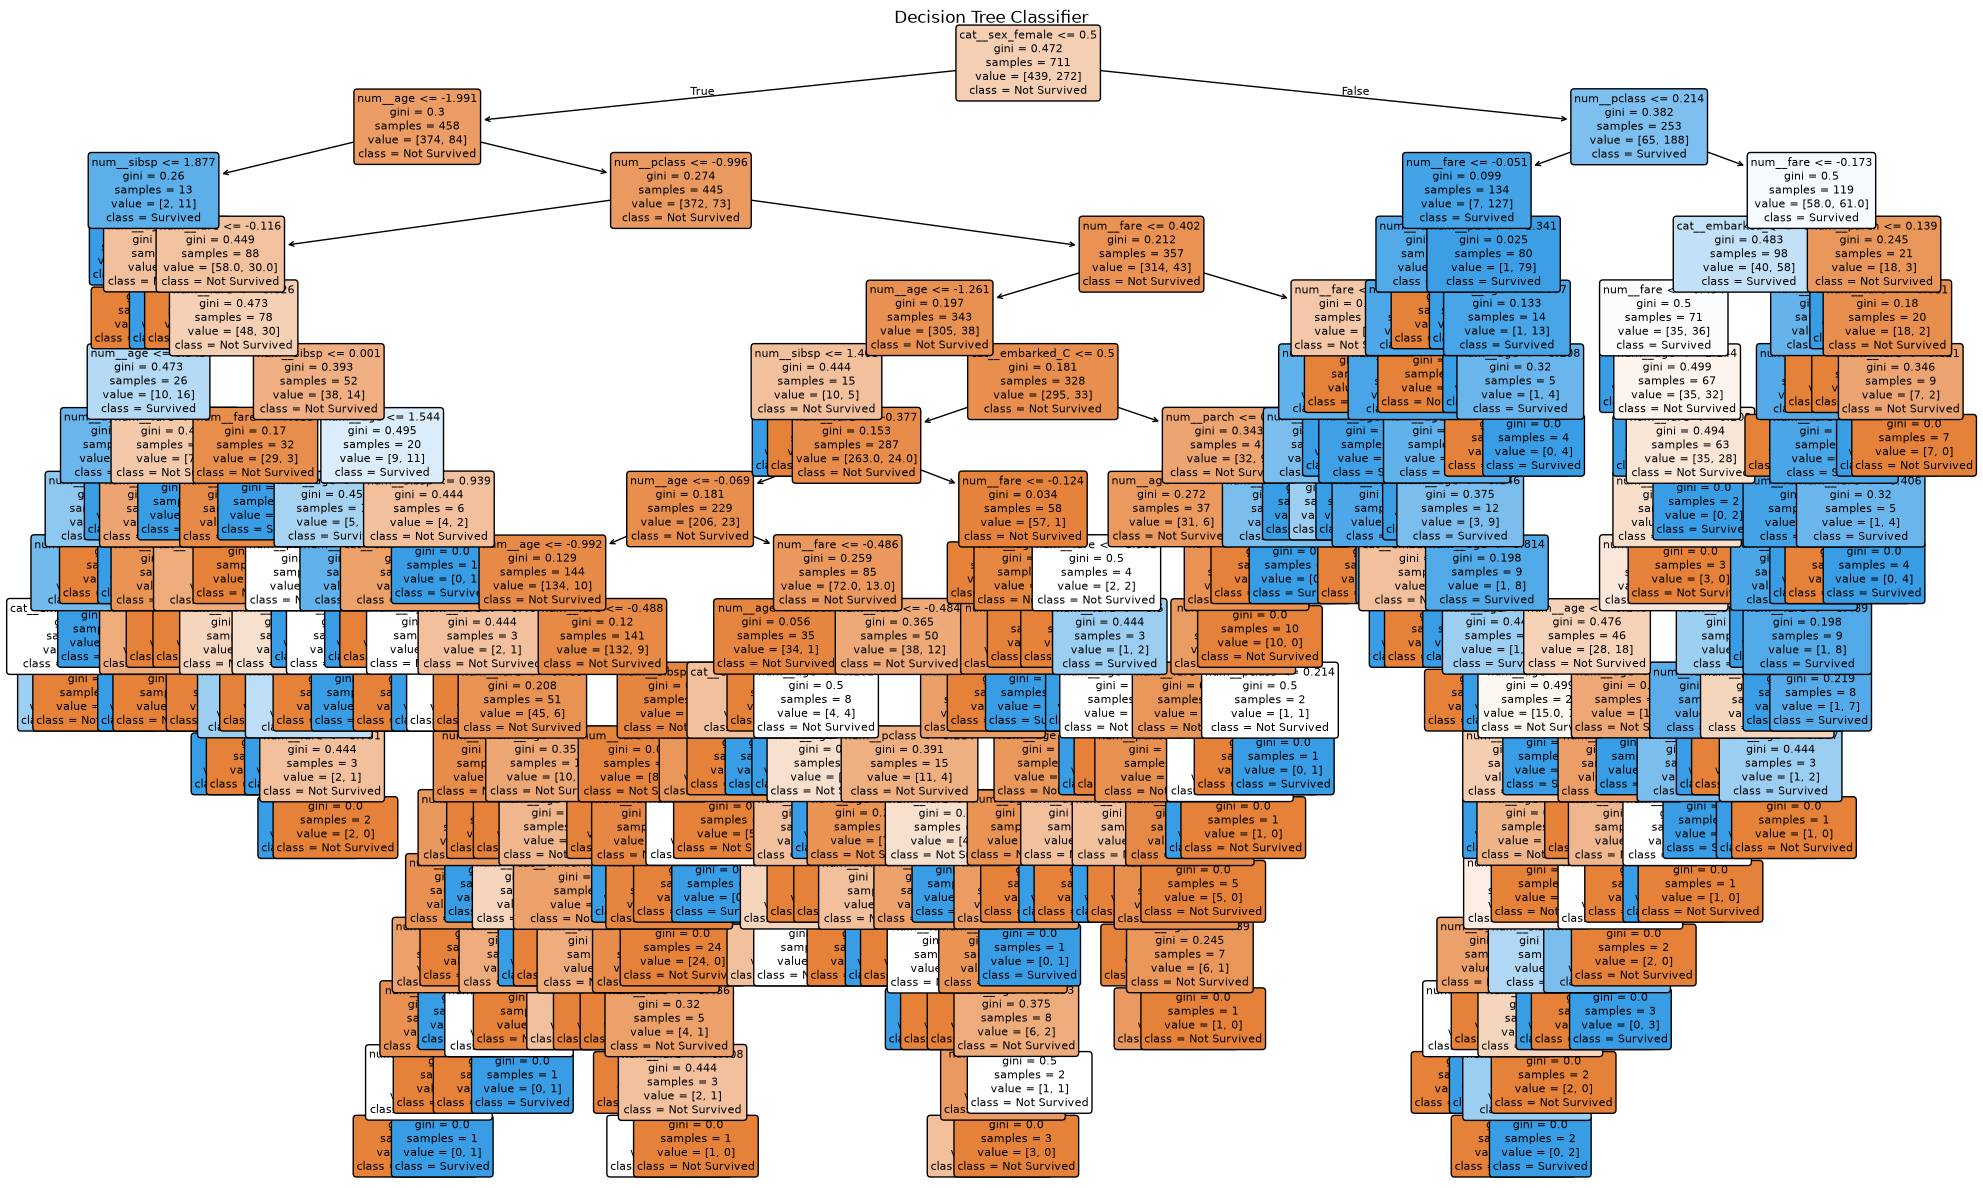

In [11]:
feature_names = decision_tree_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

decision_tree = decision_tree_pipeline.named_steps[
    "classifier"
]

plt.figure(figsize=(20, 12))

plot_tree(
    decision_tree,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.tight_layout()
plt.show()


## Model Evaluation

The performance of the trained classification models is evaluated using **Accuracy**, **Precision**, **Recall**, **F1 Score**, **AUC**, confusion matrices, and ROC curves. The evaluation metrics are summarized in a comparison table to facilitate a consistent performance comparison across all classifiers.


In [12]:
y_pred_lr = logistic_regression_pipeline.predict(X_test)
y_proba_lr = logistic_regression_pipeline.predict_proba(X_test)[:, 1]

y_pred_dt = decision_tree_pipeline.predict(X_test)
y_proba_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = random_forest_pipeline.predict(X_test)
y_proba_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]


In [13]:
models = [
    ("Logistic Regression", y_pred_lr, y_proba_lr),
    ("Decision Tree", y_pred_dt, y_proba_dt),
    ("Random Forest", y_pred_rf, y_proba_rf)
]


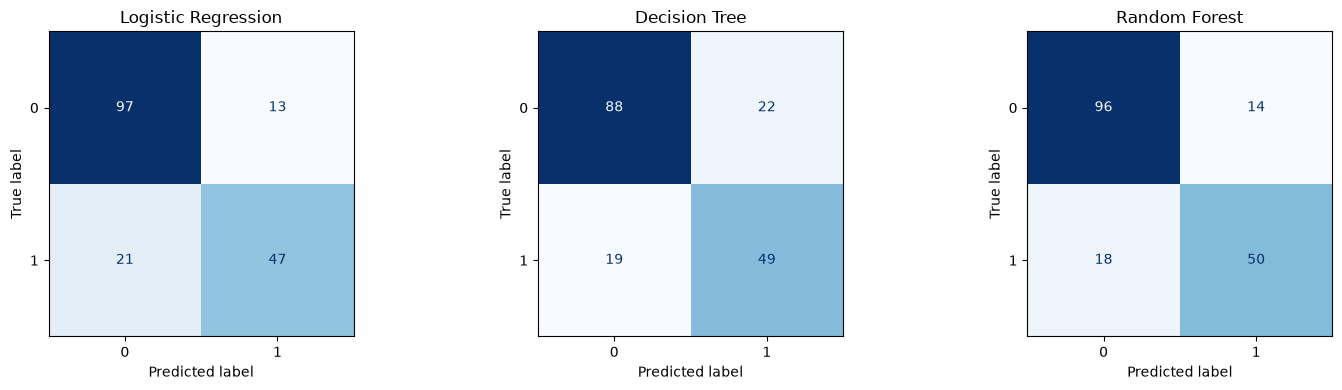

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, predictions, _) in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()


In [15]:
results = []

for name, pred, proba in models:

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    })

comparison_df = pd.DataFrame(results).round(4)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8184


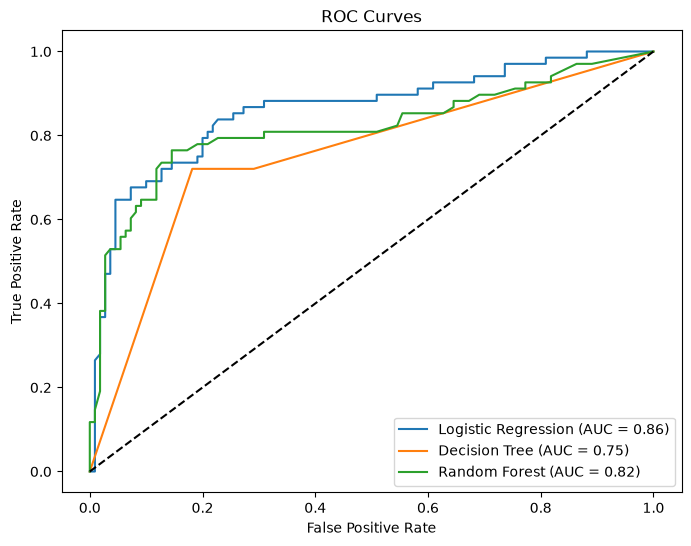

In [16]:
plt.figure(figsize=(8, 6))

for name, _, proba in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.2f})"
    )

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()


Random Forest achieved the highest overall classification performance and is selected as the strongest baseline model for further optimization.


## Class Imbalance Handling

A classification model is trained using three approaches: the baseline model, **class_weight='balanced'**, and **SMOTE** applied only to the training data. Their performance is compared using Precision, Recall, and F1 Score to determine the most effective strategy.


In [17]:
class_balance = y.value_counts()
print(class_balance)

print("\nPercentage Distribution")
print((y.value_counts(normalize=True) * 100).round(2))


survived
0    549
1    340
Name: count, dtype: int64

Percentage Distribution
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [18]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]
)

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)


In [19]:
balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)


In [20]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed, 
    y_train
)

smote_model = LogisticRegression(
    random_state=42,
    max_iter=100
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_model.predict(X_test_processed)


In [21]:
results = []

imbalance_models = [
    ("baseline", baseline_pred),
    ("class_weight='balanced'", balanced_pred),
    ("SMOTE", smote_pred)
]

for name, pred in imbalance_models:

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

imp_comparison_df = pd.DataFrame(results)
imp_comparison_df = imp_comparison_df.round(4)
display(imp_comparison_df)


,Model,Precision,Recall,F1 Score
0,baseline,0.7833,0.6912,0.7344
1,class_weight='balanced',0.7183,0.7500,0.7338
2,SMOTE,0.7353,0.7353,0.7353


Class weighting and SMOTE were evaluated to address class imbalance. Their performance was compared against the baseline Logistic Regression model.


## Hyperparameter Tuning

The **Random Forest Classifier** is optimized using **GridSearchCV** by tuning the number of estimators, maximum tree depth, and maximum features considered at each split. The best hyperparameter combination, cross-validation performance, and **Out-of-Bag (OOB) Score** are reported to evaluate the optimized model.


In [22]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__max_features": ["sqrt", "log2"]
}


In [23]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [24]:
best_model = grid_search.best_estimator_
best_classifier = best_model.named_steps['classifier']

print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"OOB Score: {best_classifier.oob_score_:.4f}")


Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation Score: 0.7434
OOB Score: 0.8073


In [25]:
y_pred_rf_tuned = best_model.predict(X_test)
y_proba_rf_tuned = best_model.predict_proba(X_test)[:, 1]


In [26]:
tuned_accuracy_rf = accuracy_score(y_test, y_pred_rf_tuned)
tuned_precision_rf = precision_score(y_test, y_pred_rf_tuned)
tuned_f1_rf = f1_score(y_test, y_pred_rf_tuned)
tuned_auc_rf = roc_auc_score(y_test, y_proba_rf_tuned)
tuned_recall_rf = recall_score(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest Accuracy: {tuned_accuracy_rf:.4f}")
print(f"Tuned Random Forest Precision: {tuned_precision_rf:.4f}")
print(f"Tuned Random Forest Recall: {tuned_recall_rf:.4f}")
print(f"Tuned Random Forest F1 Score: {tuned_f1_rf:.4f}")
print(f"Tuned Random Forest AUC: {tuned_auc_rf:.4f}")


Tuned Random Forest Accuracy: 0.8090
Tuned Random Forest Precision: 0.7656
Tuned Random Forest Recall: 0.7206
Tuned Random Forest F1 Score: 0.7424
Tuned Random Forest AUC: 0.8211


GridSearchCV identified the optimal Random Forest hyperparameters, improving the model while retaining the complete preprocessing pipeline.


## Regression Side-Task

A multivariate **Linear Regression** model is developed to predict passenger **fare** using the remaining available features. The regression model is evaluated using **MAE**, **RMSE**, **R2**, and **Adjusted R2**, while a residual plot is used to assess whether the prediction errors exhibit heteroscedasticity.


In [27]:
X_fare = df.drop(columns=['fare'])
y_fare = df['fare']

X_train_fare, X_test_fare, y_train_fare, y_test_fare = train_test_split(
    X_fare, y_fare, test_size=0.2, random_state=42
)


In [28]:
num_features_fare = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

cat_features_fare = [
    "sex",
    "embarked"
]

num_transformer_fare = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

cat_transformer_fare = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)


In [29]:
preprocessor_fare = ColumnTransformer(
    transformers=[
        ("num", num_transformer_fare, num_features_fare),
        ("cat", cat_transformer_fare, cat_features_fare)
    ]
)

fare_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fare),
        ("regressor", LinearRegression())
    ]
)

fare_pipeline.fit(X_train_fare, y_train_fare)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['survived','pclass','sex',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis con

In [30]:
y_pred_fare = fare_pipeline.predict(X_test_fare)


In [31]:
mae_fare = mean_absolute_error(y_test_fare, y_pred_fare)
rmse_fare = root_mean_squared_error(y_test_fare, y_pred_fare)
r2_fare = r2_score(y_test_fare, y_pred_fare)

n_fare = len(y_test_fare)
p_fare = fare_pipeline.named_steps['preprocessor'].transform(X_test_fare).shape[1]

adj_r2_fare = 1 - ( (1 - r2_fare) * (n_fare - 1) / (n_fare - p_fare - 1) )

print(f"Mean Absolute Error: {mae_fare:.4f}")
print(f"Root Mean Squared Error: {rmse_fare:.4f}")
print(f"R-squared: {r2_fare:.4f}")
print(f"Adjusted R-squared: {adj_r2_fare:.4f}")


Mean Absolute Error: 21.1386
Root Mean Squared Error: 41.7465
R-squared: 0.3468
Adjusted R-squared: 0.3118


### Residual Plot

The residual plot shows a non-random spread of residuals, with the variance changing across the range of predicted values. This indicates the presence of heteroscedasticity, meaning that the assumption of constant variance is violated. Consequently, the model's prediction errors are not consistent across all fare values.


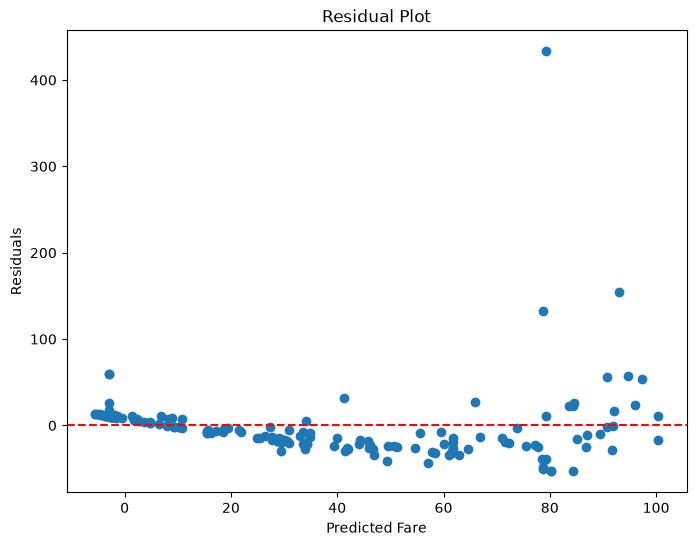

In [32]:
residuals_fare = y_test_fare - y_pred_fare

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_fare, residuals_fare)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


## Model Comparison

The performance of the classification models and the regression model is summarized using separate evaluation tables. Classification models are compared using **Accuracy**, **Precision**, **Recall**, **F1 Score**, and **AUC**, while the regression model is evaluated using **MAE**, **RMSE**, **R2**, and **Adjusted R2**.


In [33]:
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8184


In [34]:
reg_comparison = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_fare],
    "RMSE": [rmse_fare],
    "R2": [r2_fare],
    "Adjusted R2": [adj_r2_fare]
}).round(4)

display(reg_comparison)


,Model,MAE,RMSE,R2,Adjusted R2
0,Linear Regression,21.1386,41.7465,0.3468,0.3118


### Recommendation of Model to Deploy

Among the three classification models, the **Random Forest Classifier** demonstrated the strongest overall performance and is recommended for deployment. It achieved the highest Accuracy (**0.8202**) and F1 Score (**0.7576**), indicating the best balance between precision (**0.7812**) and recall (**0.7353**) of the three models. It correctly identifies more true survivors than Logistic Regression (recall 0.6912) without sacrificing as much precision as the Decision Tree. Although Logistic Regression performed competitively, Random Forest provided better overall predictive performance across the evaluation metrics. Therefore, Random Forest is the preferred model for deployment on the Titanic survival prediction.


## Save the Best Model Pipeline

The best-performing machine learning pipeline, is saved using **Joblib**. The saved pipeline is then reloaded and tested on raw, unprocessed input data to verify that it performs end-to-end preprocessing and prediction correctly.


In [35]:
best_model = grid_search.best_estimator_

joblib.dump(best_model, 'best_model.pkl')
print("Model saved successfully!")


Model saved successfully!


In [36]:
load_model = joblib.load('best_model.pkl')


In [37]:
predictions = load_model.predict(X_test)
print(predictions)


[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 1 0 1 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1
 1 1 1 1 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0]


In [38]:
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8090


# Conclusion

This notebook successfully completes the predictive modeling phase by:

- Loading the cleaned Titanic dataset generated in Part A
- Splitting the dataset into training and testing sets using a stratified train-test split
- Building a preprocessing pipeline to handle missing values, encode categorical features, and standardize numerical features
- Training and evaluating **Logistic Regression**, **Decision Tree**, and **Random Forest** classification models
- Comparing the classification models using **Accuracy**, **Precision**, **Recall**, **F1 Score**, **AUC**, confusion matrices, and ROC curves
- Investigating class imbalance by comparing the baseline Logistic Regression model with **class weighting** and **SMOTE** techniques
- Performing hyperparameter tuning on the **Random Forest Classifier** using **GridSearchCV** and reporting the best parameters, cross-validation score, and out-of-bag (OOB) score
- Building a multivariate **Linear Regression** model to predict passenger **fare** and evaluating it using **MAE**, **RMSE**, **R2**, **Adjusted R2**, and residual analysis
- Comparing the performance of all classification models and summarizing the regression model using separate evaluation metric tables
- Saving the best-performing pipeline, as a reusable production-ready model using **Joblib**
